# Load required packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Epilepsy Dataset 

# Load Data

In [2]:
epilepsy = pd.read_csv('./Datasets/epilepsyOriginal.csv', sep= ',', decimal= '.', on_bad_lines = 'error', skip_blank_lines=False)

# Check if data loaded matches source 

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
epilepsy.head() 

,Age,Gender,Weight,Height,Medication Status,Alcohol or Drug Use,EEG Abnormality Detected,MRI/CT Scan Result,Seizure Frequency,Seizure Duration,Seizure Type,Aura Before Seizure,Loss of Consciousness,Muscle Stiffness,Jerky Movements,Postictal Confusion,Blank Stare Episodes,Eye Rolling,Stress or Anxiety Before Episode,Lack of Sleep Before Episode,Flashing Lights Sensitivity,Loud Sound Sensitivity,Missed Medication,Family History of Epilepsy,Head Injury History,Brain Tumor,History of Stroke,Genetic Disorder,Developmental Delay (in Children),Epilepsy Type
0,15,Male,48.3,168.2,On Medication,Yes,Yes,Normal,1,60,Tonic-Clonic,No,Yes,No,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,No,No,No,No,Yes,Generalized
1,4,Female,56.0,174.5,On Medication,No,Yes,Abnormal,1,30,Generalized,Yes,Yes,Yes,Yes,Yes,No,No,No,No,No,No,No,Yes,Yes,Yes,No,No,No,Generalized
2,36,Female,44.8,156.2,On Medication,No,Yes,Abnormal,3,30,Tonic-Clonic,Yes,No,Yes,Yes,No,Yes,Yes,Yes,No,No,Yes,Yes,Yes,No,No,No,No,No,Generalized
3,32,Female,70.4,180.4,Not on Medication,No,Yes,Not Done,0,60,Focal,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,No,No,No,No,No,No,No,Focal
4,29,Male,54.5,161.7,On Medication,No,Yes,Not Done,1,60,Tonic-Clonic,No,Yes,Yes,Yes,Yes,No,No,Yes,No,No,Yes,No,Yes,No,Yes,No,No,No,Generalized


In [5]:
epilepsy.tail()

,Age,Gender,Weight,Height,Medication Status,Alcohol or Drug Use,EEG Abnormality Detected,MRI/CT Scan Result,Seizure Frequency,Seizure Duration,Seizure Type,Aura Before Seizure,Loss of Consciousness,Muscle Stiffness,Jerky Movements,Postictal Confusion,Blank Stare Episodes,Eye Rolling,Stress or Anxiety Before Episode,Lack of Sleep Before Episode,Flashing Lights Sensitivity,Loud Sound Sensitivity,Missed Medication,Family History of Epilepsy,Head Injury History,Brain Tumor,History of Stroke,Genetic Disorder,Developmental Delay (in Children),Epilepsy Type
719,18,Male,62.8,168.5,On Medication,No,Yes,Abnormal,1,60,Tonic-Clonic,No,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,No,Yes,No,No,No,No,No,No,Generalized
720,36,Female,69.2,168.3,On Medication,No,Yes,Abnormal,3,30,Generalized,Yes,No,No,No,Yes,Yes,No,Yes,Yes,Yes,No,No,No,No,No,No,No,No,Generalized
721,54,Female,73.9,168.0,On Medication,No,Yes,Normal,2,90,Focal,Yes,Yes,No,Yes,Yes,No,No,Yes,No,Yes,No,No,No,Yes,No,No,No,No,Focal
722,44,Female,55.1,171.7,Not on Medication,No,Yes,Not Done,0,60,Focal,No,Yes,Yes,No,Yes,No,Yes,Yes,No,Yes,No,No,No,Yes,No,No,No,No,Focal
723,65,Female,50.9,169.4,On Medication,No,Yes,Abnormal,10,120,Focal,Yes,Yes,Yes,Yes,No,Yes,No,Yes,Yes,No,Yes,Yes,No,Yes,No,No,No,No,Focal


The number of rows and columns matches csv file. 

In [6]:
pd.reset_option('display.max_columns')

# Data Cleaning

## Duplicated Rows

using .duplicated function to check duplicated rows and there are none. 

In [7]:
duplicate_mask = epilepsy.duplicated()
print("No. of duplicated rows:",duplicate_mask.sum())

No. of duplicated rows: 0


## Check data types
using dtypes and value_counts(), we can check the data types in this dataset and its corresponding count. This dataset consists of 25 string/text, 2 integer, and 2 float variables.

In [8]:
epilepsy.dtypes

Age                                    int64
Gender                                   str
Weight                               float64
Height                               float64
Medication Status                        str
Alcohol or Drug Use                      str
EEG Abnormality Detected                 str
MRI/CT Scan Result                       str
Seizure Frequency                      int64
Seizure Duration                       int64
Seizure Type                             str
Aura Before Seizure                      str
Loss of Consciousness                    str
Muscle Stiffness                         str
Jerky Movements                          str
Postictal Confusion                      str
Blank Stare Episodes                     str
Eye Rolling                              str
Stress or Anxiety Before Episode         str
Lack of Sleep Before Episode             str
Flashing Lights Sensitivity              str
Loud Sound Sensitivity                   str
Missed Med

In [9]:
epilepsy.dtypes.value_counts()

str        25
int64       3
float64     2
Name: count, dtype: int64

## String Data Type / Categorical Data

### Remove leading/trailing whitespace on variables with String data type 

Using the column names, we can check its type using .dtypes. If it is a string, we can remove any leading or trailing whitespaces.

In [10]:
# get column names 
col_names_all = epilepsy.columns.tolist()

for col_name in col_names_all:
    if(epilepsy[col_name].dtypes == 'string'):
        epilepsy[col_name] = epilepsy[col_name].str.strip()

### Correcting "Data Entry Mistakes" 

We can use value_counts to see the unique values and its corresponding count. 

In [11]:
for colname in col_names_all: 
    if epilepsy[colname].dtypes == 'string': 
        print(epilepsy[colname].value_counts().sort_index())
        print("-"*100)

Gender
Female    321
Male      390
Other      13
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Medication Status
Not on Medication    186
On Medication        538
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Alcohol or Drug Use
No     633
Yes     91
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
EEG Abnormality Detected
No      89
Yes    635
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
MRI/CT Scan Result
Abnormal    270
Normal      338
Not Done    116
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Seizure Type
Absence          20
Focal           261
Generalized     284
Tonic-Clonic    159

By observing the values above, there are no abnormal values for variables with string datatype. 

### Check for NULL/empty values

Using .isnull() and .sum(), we can see there are no NULL values.

In [12]:
# columns with NULL/empty values for STRING data type
string_df = epilepsy.select_dtypes('string')
string_df.isnull().sum()

Gender                               0
Medication Status                    0
Alcohol or Drug Use                  0
EEG Abnormality Detected             0
MRI/CT Scan Result                   0
Seizure Type                         0
Aura Before Seizure                  0
Loss of Consciousness                0
Muscle Stiffness                     0
Jerky Movements                      0
Postictal Confusion                  0
Blank Stare Episodes                 0
Eye Rolling                          0
Stress or Anxiety Before Episode     0
Lack of Sleep Before Episode         0
Flashing Lights Sensitivity          0
Loud Sound Sensitivity               0
Missed Medication                    0
Family History of Epilepsy           0
Head Injury History                  0
Brain Tumor                          0
History of Stroke                    0
Genetic Disorder                     0
Developmental Delay (in Children)    0
Epilepsy Type                        0
dtype: int64

## Integer/Float/Quantitative Data

### Check for NULL/empty values

Using .isnull() and .sum(), we can see there are no NULL values.

In [13]:
# columns with NULL/empty values for STRING data type
string_df = epilepsy.select_dtypes(['integer','float'])
string_df.isnull().sum()

Age                  0
Weight               0
Height               0
Seizure Frequency    0
Seizure Duration     0
dtype: int64

### Impossible values

In [14]:
quantitative_cols = epilepsy.select_dtypes(['integer','float']).columns.to_list()

#### Box plot to check for outliers

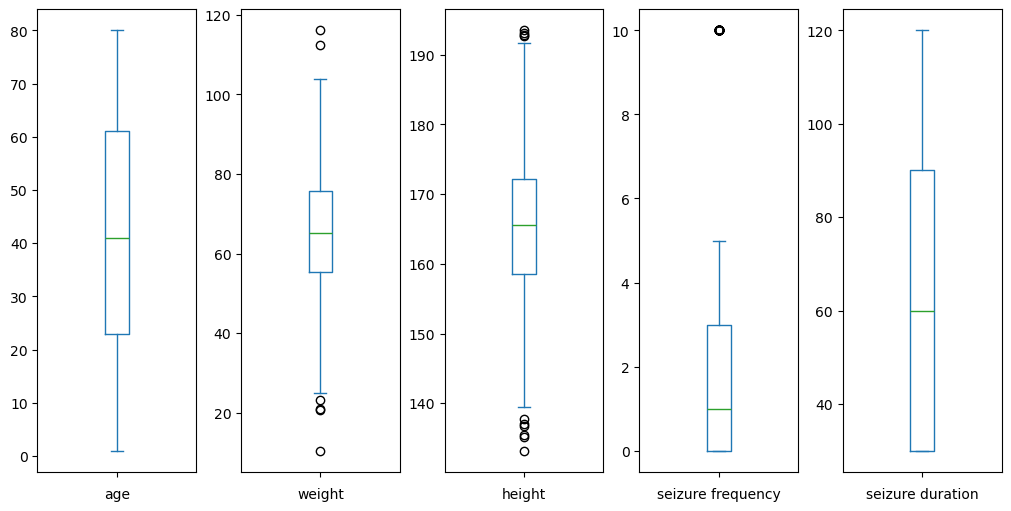

In [15]:
fig = plt.figure(figsize=(10, 5), constrained_layout=True)
axs = fig.subplots(1, 5)

for i, col in enumerate(quantitative_cols): 
    ax = axs[i]
    epilepsy[col].plot(kind = 'box', ax = ax)
    ax.set_xlabel(col.lower(), fontsize = 10)
    ax.set_xticklabels('')

From the boxplots above, we can observe that there are some outliers in variables weight, height, and seizure. These outliers will be investigated using descriptive statistics and scatter plots. The statistics plot can be found below this cell. 

#### Statistics

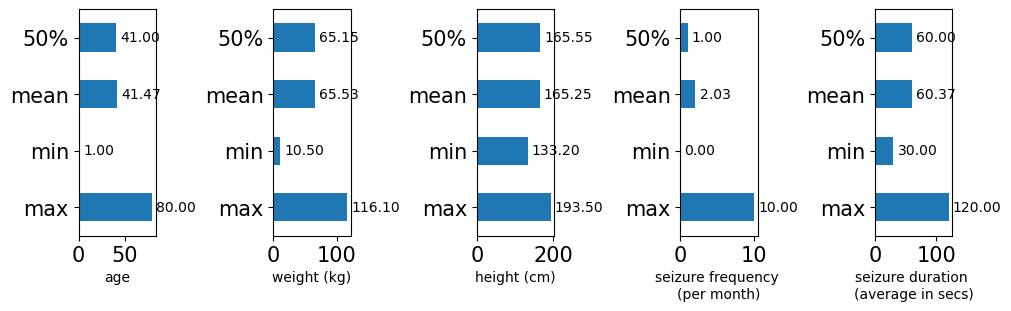

In [16]:
fig = plt.figure(figsize=(10, 3), constrained_layout=True)
axs = fig.subplots(1, 5)

for i, col in enumerate(quantitative_cols): 
    ax = axs[i]
    
    summary = epilepsy[col].describe()[['max', 'min','mean', '50%']]
    bars = summary.plot(kind='barh', ax=ax)

    # Add labels at the end of each horizontal bar
    ax.bar_label(bars.containers[0], labels=[f'{v:.2f}' for v in summary.values], padding=3)

    if(col.lower() == 'weight'): 
        col = col.lower() + ' (kg)'
    elif(col.lower() == 'height'): 
        col = col.lower() + ' (cm)'
    elif(col.lower() == 'seizure frequency'): 
        col = col.lower() + ' \n(per month)'
    elif(col.lower() == 'seizure duration'): 
        col = col.lower() + ' \n(average in secs)'
        
    ax.set_xlabel(col.lower(), fontsize = 10)
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize =15)

The statistics tells us that the minimum age is 1 year old. By looking at the Weight vs Age and Height vs Age scatter plots below, age 1 has corresponding weights heavier than 20kg and heights taller than 150cm which is physically impossible. This is indicated using the red lines in the plots.

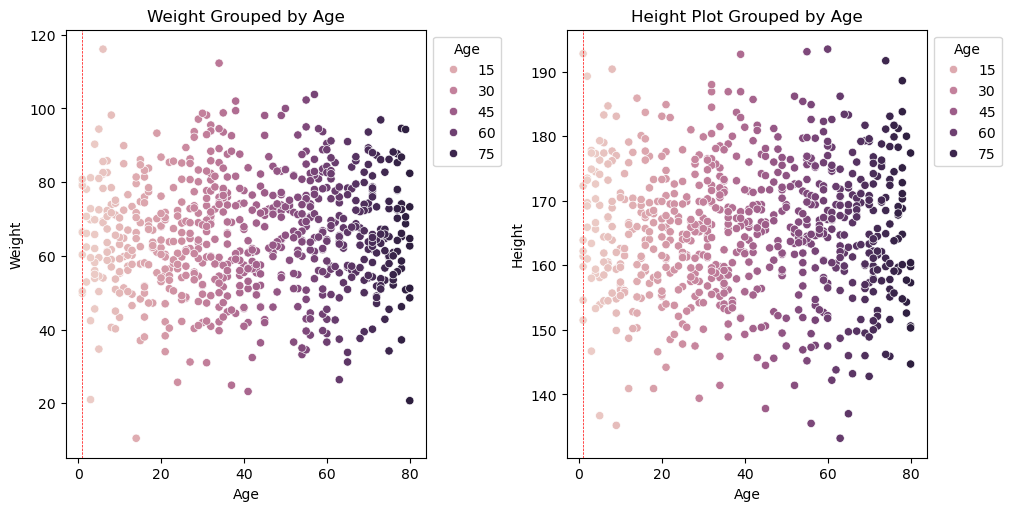

In [21]:
fig = plt.figure(figsize=(10, 5), constrained_layout=True)
axs = fig.subplots(1, 2)

# scatter plot for Weight vs Age
sns.scatterplot(data=epilepsy, x="Age", y="Weight", hue="Age", ax=axs[0])

axs[0].set_title("Weight Grouped by Age")

axs[0].axvline(x=1, color="red", linestyle="--", linewidth=0.5)

sns.move_legend(axs[0], loc="upper left", bbox_to_anchor=(1, 1))

# Scatter plot for Height vs Age
ax = sns.scatterplot(data=epilepsy, x="Age", y="Height", hue="Age", ax=axs[1])

axs[1].set_title("Height Plot Grouped by Age")

axs[1].axvline(x=1, color="red", linestyle="--", linewidth=0.5)

sns.move_legend(axs[1], loc="upper left", bbox_to_anchor=(1, 1))

As epilepsy is triggered by different causes at different age, a set of predefined values are used to check for Biologically Implausible Values(BVI). This values are found using Growth Charts by World Health Orgaisation (WHO) found on The Royoal Children's Hospital Melbourne Website[1]. It is split into age 6 age groups. Ages "0 to 2", "3 to 20 years old. 

- [1] https://www.rch.org.au/childgrowth/About_child_growth/Growth_charts/

In [18]:
def clean_weight_height_data(df):
    # Copy of original dataset to work on
    df_copy = df.copy()

    # Calculate Body Mass Index (BMI)
    # BMI = weight (kg) / (height (m))^2
    height_meters = df_copy["Height"] / 100.0
    df_copy["bmi"] = df_copy["Weight"] / (height_meters**2)

    # 2. Set (Biologically Implausible Values)
    # Age 0 to 2, bmi not included as it isn't appropriate
    age_0_1 = df_copy["Age"] <= 1
    age_0_1 = age_0_1 & (
        (df_copy["Weight"] > 14.5)
        | (df_copy["Weight"] < 2.5)  
        | (df_copy["Height"] > 94)
        | (df_copy["Height"] < 45)  
    )

    # Age 2 to 5, 
    age_2_5 = (df_copy["Age"] >=2) & (df_copy["Age"] <= 5)
    age_2_5= age_2_5 & (
        (df_copy["Weight"] > 25)
        | (df_copy["Weight"] < 10)  
        | (df_copy["Height"] > 117)
        | (df_copy["Height"] < 79)
        | (df_copy["bmi"] > 18.5)
        | (df_copy["bmi"] < 13)
    )

    #  Age 6 to 10, bmi included 
    age_6_10 = (df_copy["Age"] >= 6) & (df_copy["Age"] <= 10) 
    age_6_10 = age_6_10 & (
        (df_copy["Weight"] > 50)
        | (df_copy["Weight"] < 15)
        | (df_copy["Height"] > 150)
        | (df_copy["Height"] < 90)
        | (df_copy["bmi"] > 23.5)
        | (df_copy["bmi"] < 13.5)
    )

    # Age 10 to 15, bmi included 
    age_11_15 = (df_copy["Age"] >= 11) & (df_copy["Age"] <= 15) 
    age_11_15 = age_11_15 & (
        (df_copy["Weight"] > 85)
        | (df_copy["Weight"] < 25)
        | (df_copy["Height"] > 185)
        | (df_copy["Height"] < 125)
        | (df_copy["bmi"] > 29)
        | (df_copy["bmi"] < 14)
    )

    # Age 10 to 15, bmi included 
    age_16_20 = (df_copy["Age"] >= 16) & (df_copy["Age"] <= 20) 
    age_16_20 = age_16_20 & (
        (df_copy["Weight"] > 100)
        | (df_copy["Weight"] < 45)
        | (df_copy["Height"] > 190)
        | (df_copy["Height"] < 155)
        | (df_copy["bmi"] > 32.5)
        | (df_copy["bmi"] < 17)
    )

    
    # adults: Age >20+
    adult_mask = df_copy["Age"] > 20
    adult_mask = adult_mask & (
        (df_copy["Weight"] > 400)
        | (df_copy["Weight"] < 25)
        | (df_copy["Height"] > 200)
        | (df_copy["Height"] < 100)
        | (df_copy["bmi"] > 204)
        | (df_copy["bmi"] < 10)  
    )
    
    # full mask 
    impossible_combinations_mask = age_0_1 | age_2_5 | age_6_10 | age_11_15 | age_16_20 | adult_mask

    # filter data with full mask 
    df_cleaned = df_copy[~impossible_combinations_mask].reset_index(drop=True)

    # Print data audit metrics
    print(f"Original observations: {len(df)}")
    print(f"Removed observations: {impossible_combinations_mask.sum()}")
    print(f"Cleaned observations: {len(df_cleaned)}")
    print(f"Percentage removed: {round((impossible_combinations_mask.sum()/len(df))*100,3)}%")

    return df_cleaned
    # return None

# Run the cleaner
epilepsy_clean = clean_weight_height_data(epilepsy)
epilepsy_clean = epilepsy_clean.drop("bmi", axis = 1)

Original observations: 724
Removed observations: 103
Cleaned observations: 621
Percentage removed: 14.227%


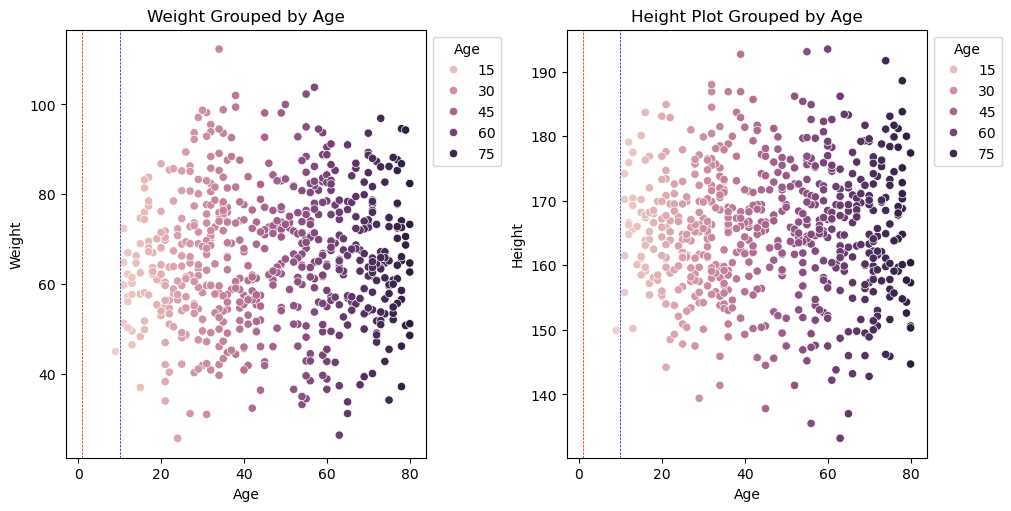

In [19]:
fig = plt.figure(figsize=(10, 5), constrained_layout=True)
axs = fig.subplots(1, 2)

current = epilepsy_clean

sns.scatterplot(data=current, x="Age", y="Weight", hue="Age", ax=axs[0])
# sns.move_legend(ax,loc="lower center", bbox_to_anchor=(1, 0.5, 0, 1))

axs[0].set_title("Weight Grouped by Age")

axs[0].axvline(x=1, color="red", linestyle="--", linewidth=0.5)
axs[0].axvline(x=10, color="blue", linestyle="--", linewidth=0.5)

sns.move_legend(axs[0], loc="upper left", bbox_to_anchor=(1, 1))

ax = sns.scatterplot(data=current, x="Age", y="Height", hue="Age", ax=axs[1])
# sns.move_legend(ax,loc="lower center", bbox_to_anchor=(1, 0.5, 0, 1))

axs[1].set_title("Height Plot Grouped by Age")

axs[1].axvline(x=1, color="red", linestyle="--", linewidth=0.5)
axs[1].axvline(x=10, color="blue", linestyle="--", linewidth=0.5)

sns.move_legend(axs[1], loc="upper left", bbox_to_anchor=(1, 1))

Figures above shows the data after removing Biologically Implausible Values. The values around red vertical line which is plotted at age = 1 and blue line is plotted at age = 10. Most of the data from ages 1 to 10 were removed. This shows that there are a lot of errors during data collection. The downside is 14% of the data is removed which is not ideal. However, age, weight, and height plays a crucial role in causes of epilepsy [1]. Hence we need to make sure these values are plausible for a better representation of real world data.

- [1] https://int.livhospital.com/epilepsy-amazing-facts-on-genetic-risks/

# Save data

We have now dealt with all categorical and numerical data. We can now save it as a clean csv.

In [24]:
epilepsy_clean.to_csv("./Datasets/epilepsyCleaned.csv")

# Data Enconding

## Encode categorical values

I will be using the cross_val function from sklearn to conduct my model parameter tuning. Method cross_val_score only accepts numerical variables[1]. Hence, encoding the categorical values are crucial. I will be using the pandas getdummies method to one hot encode my categorical variables[2]. 

- [1] https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html
- [2] https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html

In [31]:
encoded_epilepsy = pd.get_dummies(
    epilepsy_clean,
    columns=['Gender', 'Medication Status', 'Alcohol or Drug Use', 'EEG Abnormality Detected', 'MRI/CT Scan Result', 
             'Seizure Type', 'Aura Before Seizure', 'Loss of Consciousness', 'Muscle Stiffness', 'Jerky Movements', 
             'Postictal Confusion', 'Blank Stare Episodes', 'Eye Rolling', 'Stress or Anxiety Before Episode', 
             'Lack of Sleep Before Episode', 'Flashing Lights Sensitivity', 'Loud Sound Sensitivity', 'Missed Medication',
             'Family History of Epilepsy', 'Head Injury History', 'Brain Tumor', 'History of Stroke', 'Genetic Disorder',
             'Developmental Delay (in Children)'],
    drop_first=False
)

In [32]:
pd.set_option('display.max_columns', None)

In [33]:
encoded_epilepsy.head()

,Age,Weight,Height,Seizure Frequency,Seizure Duration,Epilepsy Type,Gender_Female,Gender_Male,Gender_Other,Medication Status_Not on Medication,Medication Status_On Medication,Alcohol or Drug Use_No,Alcohol or Drug Use_Yes,EEG Abnormality Detected_No,EEG Abnormality Detected_Yes,MRI/CT Scan Result_Abnormal,MRI/CT Scan Result_Normal,MRI/CT Scan Result_Not Done,Seizure Type_Absence,Seizure Type_Focal,Seizure Type_Generalized,Seizure Type_Tonic-Clonic,Aura Before Seizure_No,Aura Before Seizure_Yes,Loss of Consciousness_No,Loss of Consciousness_Yes,Muscle Stiffness_No,Muscle Stiffness_Yes,Jerky Movements_No,Jerky Movements_Yes,Postictal Confusion_No,Postictal Confusion_Yes,Blank Stare Episodes_No,Blank Stare Episodes_Yes,Eye Rolling_No,Eye Rolling_Yes,Stress or Anxiety Before Episode_No,Stress or Anxiety Before Episode_Yes,Lack of Sleep Before Episode_No,Lack of Sleep Before Episode_Yes,Flashing Lights Sensitivity_No,Flashing Lights Sensitivity_Yes,Loud Sound Sensitivity_No,Loud Sound Sensitivity_Yes,Missed Medication_No,Missed Medication_Yes,Family History of Epilepsy_No,Family History of Epilepsy_Yes,Head Injury History_No,Head Injury History_Yes,Brain Tumor_No,Brain Tumor_Yes,History of Stroke_No,History of Stroke_Yes,Genetic Disorder_No,Genetic Disorder_Yes,Developmental Delay (in Children)_No,Developmental Delay (in Children)_Yes
0,15,48.3,168.2,1,60,Generalized,False,True,False,False,True,False,True,False,True,False,True,False,False,False,False,True,True,False,False,True,True,False,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,True,False,True,False,True,False,True,False,True,False,True,False,False,True
1,36,44.8,156.2,3,30,Generalized,True,False,False,False,True,True,False,False,True,True,False,False,False,False,False,True,False,True,True,False,False,True,False,True,True,False,False,True,False,True,False,True,True,False,True,False,False,True,False,True,False,True,True,False,True,False,True,False,True,False,True,False
2,32,70.4,180.4,0,60,Focal,True,False,False,True,False,True,False,False,True,False,False,True,False,True,False,False,False,True,False,True,True,False,False,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,True,False,True,False,True,False,True,False,True,False,True,False,True,False
3,29,54.5,161.7,1,60,Generalized,False,True,False,False,True,True,False,False,True,False,False,True,False,False,False,True,True,False,False,True,False,True,False,True,False,True,True,False,True,False,False,True,True,False,True,False,False,True,True,False,False,True,True,False,False,True,True,False,True,False,True,False
4,18,62.1,168.0,1,30,Generalized,False,True,False,False,True,True,False,False,True,True,False,False,False,False,False,True,False,True,False,True,True,False,False,True,False,True,False,True,True,False,False,True,False,True,False,True,True,False,True,False,False,True,True,False,True,False,True,False,True,False,True,False


In [29]:
pd.reset_option('display.max_columns')

In [34]:
encoded_epilepsy.shape

(621, 58)

The cell above shows the one hot encoded data of epilepsy. For example, variable Gender is now split into three columns, Gender_Female, Gender_Male, and Gender_Other. The cell above with the shaalso shows shnow 621 rows We can now save it in a new csv file. 

In [ ]:
encoded_epilepsy.to_csv("./Datasets/epilepsyCleaned.csv")